In [1]:
import sqlite3
import datetime
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import contextily as ctx
from matplotlib.colors import to_rgba
import matplotlib.patches as mpatches

# Sentinel-2 machine learning dataset for tree species classification in Germany (Published in 2025)
[data access](https://www.openagrar.de/receive/openagrar_mods_00094435) \
[paper link](https://essd.copernicus.org/articles/17/351/2025/#section7) \
[some pdf illustration](https://www.openagrar.de/servlets/MCRFileNodeServlet/timport_derivate_00008979/dn055892.pdf)

## Content
1. [Load species metadata from xlsx, code -> specie name](###Load-Species)
2. [Load data, and query using sqlite3](###Load-Data)
3. [Preprocess](###Preprocess)
4. [Visualization](###Visualization)

### Load species metadata from xlsx, code -> specie name

In [2]:
# Define the path to the Excel file
excel_file_path = "data/s2species/essd-17-351-2025-t04.xlsx"
essd_table = pd.read_excel(excel_file_path)
display(essd_table.T)

# Create a species map excluding Species code = -1
species_map = {}
for _, row in essd_table.iterrows():
    if pd.notna(row['Species code']) and row['Species code'] != '−1':
        species_map[row['Species code']] = row['Species']

# species_map

,0,1,2,3,4,5,6,7,8,9,...,42,43,44,45,46,47,48,49,50,51
Species code,−1,10,12,19,20,21,22,24,25,29,...,224,230,240,250,251,252,290,292,293,295
Species,–,Picea,Picea,Picea,Pinus,Pinus,Pinus,Pinus,Pinus,Pinus,...,Populus,Sorbus,Salix,Prunus,Prunus,Prunus,NaN,Malus,Pyrus,Sorbus
Unnamed: 2,–,abies,sitchensis,spec.,sylvestris,mugo,nigra,cembra,strobus,spec.,...,trichocarpa x maximoviczii,aucuparia,spec.,padus,avium,serotina,NaN,sylvestris,communis,torminalis
Common name,Other land cover,Norway spruce,Sitka spruce,Other spruces,Scots pine,Mountain pine,European black pine,Swiss pine,Eastern white pine,Other pines,...,Balsam poplar,European rowan,Willow,Bird cherry,Wild cherry,Black cherry,Miscellaneous broadleaf trees with a short lif...,European crab apple,European wild pear,Wild service tree
Count,70 242,107 798,937,232,102 730,88,606,3,431,65,...,636,270,1203,77,1357,132,92,37,42,71


### Load data, and query using sqlite3
There is a time range from 2015 to 2022, and tree points are highly overlapped with different DBT and height.

In [3]:
# change this path to point to the database file
dataset_path = 'data/s2species/S2GNFI_V1.sqlite'
conn = sqlite3.connect(dataset_path)
conn.text_factory = bytes  # this makes sqlite return strings as bytes that we can parse via numpy

Select only 1 point for each tree location and the most recent record (ought to be 2022).

In [4]:
# select all the data group by coordinates, unique coordinates
df = pd.read_sql_query("SELECT * FROM (SELECT *, ROW_NUMBER() OVER(PARTITION BY X_WGS84, Y_WGS84 ORDER BY time DESC) as rn FROM data) \
                       WHERE rn = 1", conn)

In [9]:
print(f'Total data points (Unique tree coordinates): {len(df)}')
print('Raw data:')
display(df.head())

print('Preprocessed data:')
df = df.drop(columns=['tnr', 'enr', 'is_train', 'is_pure', 'is_corrected', 'disturbance_year'])
df.boa = [np.frombuffer(x, dtype=np.int16) for x in df.boa]
df.time = [datetime.date.fromtimestamp(t) for t in df.time]
df['year'] = pd.to_datetime(df['time'], format='%Y-%m-%d').dt.year
display(df.head())

Total data points (Unique tree coordinates): 24795
Raw data:


,tree_id,species,time,boa,qai,dbh_mm,height_dm,crown_area_m2,X_WGS84,Y_WGS84,present_2022,doy,rn,year
0,-25826,-1,2022-11-02,"[622, 740, 724, 828, 1146, 1308, 1358, 1417, 1...",2048,0,0,0.000000,NaN,NaN,1,306,1,2022
1,365630,211,2022-10-12,"[160, 264, 190, 522, 1604, 2225, 2053, 2551, 1...",10240,498,192,83.987633,5.915701,51.006786,1,285,1,2022
2,388049,110,2022-10-12,"[144, 291, 181, 505, 1866, 2595, 2955, 2691, 1...",10240,263,217,21.940088,5.944159,51.007790,1,285,1,2022
3,357356,20,2022-10-12,"[206, 324, 215, 483, 1543, 1809, 1940, 2130, 7...",10240,451,263,48.400536,5.979656,51.747009,1,285,1,2022
4,216069,110,2022-10-12,"[137, 298, 163, 557, 2041, 2481, 2472, 2763, 1...",8192,519,274,81.276810,6.002627,50.991821,1,285,1,2022


Preprocessed data:


,tree_id,species,time,boa,qai,dbh_mm,height_dm,crown_area_m2,X_WGS84,Y_WGS84,present_2022,doy,rn,year
0,-25826,-1,2022-11-02,"[622, 740, 724, 828, 1146, 1308, 1358, 1417, 1...",2048,0,0,0.000000,NaN,NaN,1,306,1,2022
1,365630,211,2022-10-12,"[160, 264, 190, 522, 1604, 2225, 2053, 2551, 1...",10240,498,192,83.987633,5.915701,51.006786,1,285,1,2022
2,388049,110,2022-10-12,"[144, 291, 181, 505, 1866, 2595, 2955, 2691, 1...",10240,263,217,21.940088,5.944159,51.007790,1,285,1,2022
3,357356,20,2022-10-12,"[206, 324, 215, 483, 1543, 1809, 1940, 2130, 7...",10240,451,263,48.400536,5.979656,51.747009,1,285,1,2022
4,216069,110,2022-10-12,"[137, 298, 163, 557, 2041, 2481, 2472, 2763, 1...",8192,519,274,81.276810,6.002627,50.991821,1,285,1,2022


In [ ]:
# # Query the database and select only one point for each unique X_WGS84, Y_WGS84 coordinate pair
# # For each coordinate pair, select the most recent record (latest time)
# df = pd.read_sql_query("SELECT * FROM (SELECT *, ROW_NUMBER() OVER(PARTITION BY X_WGS84, Y_WGS84 ORDER BY time DESC) as rn FROM data) \
#                        WHERE rn = 1 \
#                        ORDER BY random() LIMIT 100000", conn)

# df = pd.read_sql_query("SELECT * FROM data WHERE \
#                        X_WGS84 between 7.622 and 8.14 and Y_WGS84 between 49.10 and 49.47 \
#                        order by random() limit 100000", conn)

### Preprocess

In [10]:
print('years in df: ', np.unique(df['year']))
print('species in df: ', np.unique(df['species']))

years in df:  [2022]
species in df:  [ -1  10  12  19  20  21  22  24  25  29  30  33  39  40  50  51  90  94
 100 110 111 112 120 130 140 141 142 150 160 170 181 190 191 193 200 201
 211 212 220 221 222 223 224 230 240 250 251 252 290 292 293 295]
df num: 24795


In [11]:
# Quality Filtering
VALID        = 0b000000000000000
NODATA       = 0b000000000000001
CLOUD_BUFFER = 0b000000000000010
CLOUD_OPAQUE = 0b000000000000100
CLOUD_CIRRUS = 0b000000000000110
CLOUD_SHADOW = 0b000000000001000
SNOW         = 0b000000000010000
WATER        = 0b000000000100000
AOD_INT      = 0b000000001000000
AOD_HIGH     = 0b000000010000000
AOD_FILL     = 0b000000011000000
SUBZERO      = 0b000000100000000
SATURATION   = 0b000001000000000
SUN_LOW      = 0b000010000000000
ILLUMIN_LOW  = 0b000100000000000
ILLUMIN_POOR = 0b001000000000000
ILLUMIN_NONE = 0b001100000000000
SLOPED       = 0b010000000000000
WVP_NONE     = 0b100000000000000

In [13]:
# filter out cloud and snow
my_filter = CLOUD_BUFFER | CLOUD_CIRRUS | CLOUD_OPAQUE | CLOUD_SHADOW | SNOW
mask = (df["qai"] & my_filter) == 0
df = df[mask]
print(f'Total data points (after masking): {len(df)}')

Total data points (after masking): 21216


### Visualization

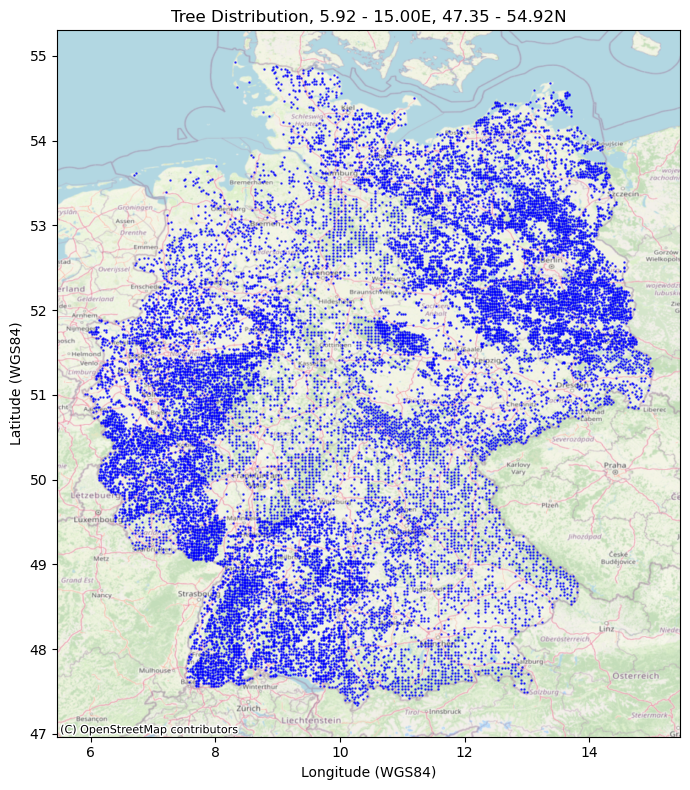

In [17]:
def plot_tree_distribution(df):
    # whole area
    fig, ax = plt.subplots(figsize=(7, 8))
    min_lat = df['Y_WGS84'].min()
    max_lat = df['Y_WGS84'].max()
    min_lon = df['X_WGS84'].min()
    max_lon = df['X_WGS84'].max()
    window = f'{min_lon:.2f} - {max_lon:.2f}E, {min_lat:.2f} - {max_lat:.2f}N'
    scatter = ax.scatter(df['X_WGS84'], df['Y_WGS84'], alpha=0.7, s=0.6, 
                        color=to_rgba('blue', 0.6), zorder=2)
    ax.set_title(f'Tree Distribution, {window}')
    ax.set_xlabel('Longitude (WGS84)')
    ax.set_ylabel('Latitude (WGS84)')

    # Add OSM basemap
    ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik, 
                    zoom=7, alpha=0.9)

    plt.tight_layout()
    plt.show()

plot_tree_distribution(df)

In [18]:
"""
select a window
"""
# Define the center coordinates and window size
center_lat = 49.367
center_lon = 7.962
window_size_km = 10  # 10km x 10km window

# Convert km to degrees (approximate conversion)
# 1 degree of latitude is approximately 111.32 km
lat_offset = window_size_km / 111.32 / 2
# Longitude degrees vary with latitude
lon_offset = window_size_km / (111.32 * np.cos(np.radians(center_lat))) / 2

# Define the bounding box
min_lat = center_lat - lat_offset
max_lat = center_lat + lat_offset
min_lon = center_lon - lon_offset
max_lon = center_lon + lon_offset

# Filter the dataframe to only include trees within the bounding box
df_window = df[(df['Y_WGS84'] >= min_lat) & 
                    (df['Y_WGS84'] <= max_lat) & 
                    (df['X_WGS84'] >= min_lon) & 
                    (df['X_WGS84'] <= max_lon)]

print(f"Selected {len(df_window)} trees within a {window_size_km}km x {window_size_km}km window centered at ({center_lat}, {center_lon})")
display(df_window.head())

Selected 19 trees within a 10km x 10km window centered at (49.367, 7.962)


,tree_id,species,time,boa,qai,dbh_mm,height_dm,crown_area_m2,X_WGS84,Y_WGS84,present_2022,doy,rn,year
4791,435954,100,2022-09-09,"[212, 357, 217, 605, 2285, 2945, 3311, 3222, 1...",8192,346,251,28.384399,7.899276,49.395817,1,252,1,2022
4793,349257,10,2022-09-09,"[182, 282, 159, 457, 1377, 1861, 1905, 2116, 8...",8192,463,346,35.030991,7.900050,49.377838,1,252,1,2022
4800,122473,100,2022-09-24,"[157, 303, 175, 564, 2313, 3259, 3720, 3782, 1...",8192,437,302,44.608112,7.902366,49.323902,1,267,1,2022
4930,471059,20,2022-09-24,"[263, 404, 314, 649, 1830, 2287, 2326, 2469, 1...",8192,206,157,10.357923,7.926814,49.396328,1,267,1,2022
4935,470918,111,2022-09-24,"[181, 359, 177, 559, 2836, 3800, 4221, 3991, 1...",0,238,241,17.408920,7.927577,49.378349,1,267,1,2022


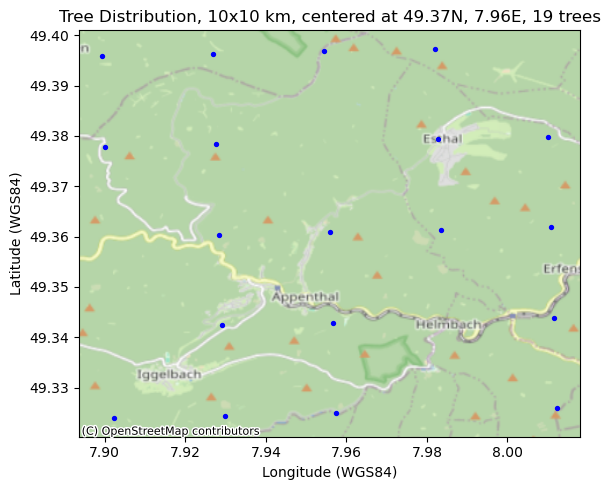

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))
# Add points at tree centers
scatter = ax.scatter(df_window['X_WGS84'], df_window['Y_WGS84'], alpha=1, s=8, 
                    color=to_rgba('blue', 1), zorder=8)
ax.set_title(f'Tree Distribution, {window_size_km}x{window_size_km} km, centered at {center_lat:.2f}N, {center_lon:.2f}E, {len(df_window)} trees')
ax.set_xlabel('Longitude (WGS84)')
ax.set_ylabel('Latitude (WGS84)')

# Add OSM basemap
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik, 
                zoom=12, alpha=0.9)

plt.tight_layout()
plt.show()


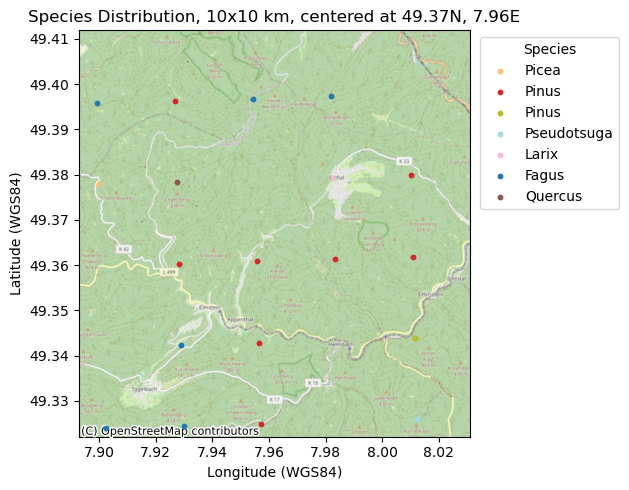

In [25]:
# Create a scatter plot of the selected window
fig, ax = plt.subplots(figsize=(7, 5))

# Create a color map for different species
# Get unique species codes
species_codes = df_window['species'].unique()
# Create a color map directly for species codes
colors = plt.cm.tab20(np.linspace(0, 1, len(species_codes)))
species_color_map = dict(zip(species_codes, colors))

# Add points at tree centers with colors by species
scatter_points = []
for species, group in df_window.groupby('species'):
    species_name = species_map.get(species, f"Unknown ({species})")
    scatter = ax.scatter(group['X_WGS84'], group['Y_WGS84'], 
                         alpha=1, s=10, 
                         color=species_color_map[species], 
                         label=species_name, zorder=30)
    scatter_points.append(scatter)

# Set plot limits to the window boundaries
ax.set_xlim(min_lon, max_lon)
ax.set_ylim(min_lat, max_lat)
ax.set_title(f'Species Distribution, {window_size_km}x{window_size_km} km, centered at {center_lat:.2f}N, {center_lon:.2f}E')
ax.set_xlabel('Longitude (WGS84)')
ax.set_ylabel('Latitude (WGS84)')

# Add OSM basemap
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik, 
                zoom=13, alpha=0.9)

# Add legend for species
ax.legend(loc='best', title='Species', bbox_to_anchor=(1.4, 1))

plt.tight_layout()
plt.show()